In [109]:
# Library imports
import datetime as datetime
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.tri as tri

In [110]:
# Read in FVCOM data
fvcom_data_path = "~/shared-public/ohw26/model_downsampling/stmb_fvcom_weekly_avg_temp.nc"
stmb_fvcom = xr.open_dataset(fvcom_data_path)
stmb_fvcom

<xarray.Dataset> Size: 177MB
Dimensions:        (time: 53, nele: 7697, node: 4247, siglay: 20, siglev: 21,
                    three: 3, maxnode: 10, maxelem: 8, four: 4)
Coordinates:
    siglev         (siglev, node) float32 357kB ...
    siglay         (siglay, node) float32 340kB ...
    lon            (node) float32 17kB ...
    lat            (node) float32 17kB ...
    lonc           (nele) float32 31kB ...
    latc           (nele) float32 31kB ...
  * time           (time) datetime64[ns] 424B 2016-12-31 ... 2017-12-30
Dimensions without coordinates: nele, node, three, maxnode, maxelem, four
Data variables: (12/27)
    nprocs         (time) float64 424B ...
    partition      (time, nele) int32 2MB ...
    x              (time, node) float32 900kB ...
    y              (time, node) float32 900kB ...
    xc             (time, nele) float32 2MB ...
    yc             (time, nele) float32 2MB ...
    ...             ...
    awx            (time, three, nele) float32 5MB ...
    awy            (time, three, nele) float32 5MB ...
    art2           (time, node) float32 900kB ...
    art1           (time, node) float32 900kB ...
    omega          (time, siglev, node) float32 19MB ...
    temp           (time, siglay, node) float32 18MB ...

In [118]:
# Read in in-situ observation data with lat, lon, and depth
station_data_path = "~/shared-public/ohw26/model_downsampling/cmar_sensor_heights.csv"
station_data = pd.read_csv(station_data_path)
station_location_data = station_data.drop_duplicates(subset=["station", "latitude", "longitude"])
station_location_data

,station,latitude,longitude,station_depth_m,sensor_depth_at_low_tide_m,sensor_height_above_seafloor_m
0,1012,44.407102,-66.160532,21,1.0,20.0
3,5007,44.539117,-65.957983,6,1.3,4.7
5,5008,44.503833,-65.932367,5,1.0,4.0
7,Centreville 1,44.532800,-65.984040,10,2.0,8.0
10,Centreville,44.536239,-66.001720,4,3.5,0.5
11,Church Point 1,44.324017,-66.135683,11,4.0,7.0
15,Church Point 2,44.320150,-66.135067,10,2.0,8.0
19,Long Beach 1,44.381841,-66.177394,44,2.0,42.0
25,Long Beach,44.401726,-66.159589,30,2.0,28.0
31,Long Island 1,44.350130,-66.224300,34,2.0,32.0


In [119]:
# Add longitude on 0-360 scale for stations
old_lon = station_location_data["longitude"]
new_lon = np.where(old_lon < 180, old_lon + 360, old_lon)
station_location_data["longitude_360"] = new_lon
station_location_data

,station,latitude,longitude,station_depth_m,sensor_depth_at_low_tide_m,sensor_height_above_seafloor_m,longitude_360
0,1012,44.407102,-66.160532,21,1.0,20.0,293.839468
3,5007,44.539117,-65.957983,6,1.3,4.7,294.042017
5,5008,44.503833,-65.932367,5,1.0,4.0,294.067633
7,Centreville 1,44.532800,-65.984040,10,2.0,8.0,294.015960
10,Centreville,44.536239,-66.001720,4,3.5,0.5,293.998280
11,Church Point 1,44.324017,-66.135683,11,4.0,7.0,293.864317
15,Church Point 2,44.320150,-66.135067,10,2.0,8.0,293.864933
19,Long Beach 1,44.381841,-66.177394,44,2.0,42.0,293.822606
25,Long Beach,44.401726,-66.159589,30,2.0,28.0,293.840411
31,Long Island 1,44.350130,-66.224300,34,2.0,32.0,293.775700


In [120]:
# Get node coordinates from FVCOM mesh
node_lat = stmb_fvcom.lat.values
node_lon = stmb_fvcom.lon.values

In [121]:
# Define a function to calculate haversine distance
def haversine_distance(lat1, lon1, lat2, lon2):
    """Great-circle distance (meters) between two points"""
    R = 6371000.0 # Earth radius in meters
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    lat_diff = lat2 - lat1
    lon_diff = lon2 - lon1
    a = np.sin(lat_diff / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(lon_diff / 2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

In [122]:
# Loop over all of the stations to find the nearest node for each
# Looping will take more time but less memory 
# than building a huge numpy array with a dense mesh

nearest_nodes = np.empty(len(station_location_data), dtype=int)
node_dists = np.empty(len(station_location_data), dtype=float)

for i, station in enumerate(station_location_data.itertuples()):
    dist = haversine_distance(station.latitude, station.longitude_360, node_lat, node_lon)
    nearest_nodes[i] = int(np.argmin(dist))
    node_dists[i] = dist[nearest_nodes[i]]

station_location_data["nearest_node"] = nearest_nodes
station_location_data["node_dist"] = node_dists
station_location_data

,station,latitude,longitude,station_depth_m,sensor_depth_at_low_tide_m,sensor_height_above_seafloor_m,longitude_360,nearest_node,node_dist
0,1012,44.407102,-66.160532,21,1.0,20.0,293.839468,2396,61.925953
3,5007,44.539117,-65.957983,6,1.3,4.7,294.042017,3833,129.799600
5,5008,44.503833,-65.932367,5,1.0,4.0,294.067633,3868,265.010320
7,Centreville 1,44.532800,-65.984040,10,2.0,8.0,294.015960,3748,314.784067
10,Centreville,44.536239,-66.001720,4,3.5,0.5,293.998280,3779,246.791850
11,Church Point 1,44.324017,-66.135683,11,4.0,7.0,293.864317,1793,223.514764
15,Church Point 2,44.320150,-66.135067,10,2.0,8.0,293.864933,1727,290.188437
19,Long Beach 1,44.381841,-66.177394,44,2.0,42.0,293.822606,2034,155.436617
25,Long Beach,44.401726,-66.159589,30,2.0,28.0,293.840411,2301,86.842661
31,Long Island 1,44.350130,-66.224300,34,2.0,32.0,293.775700,1601,197.691855


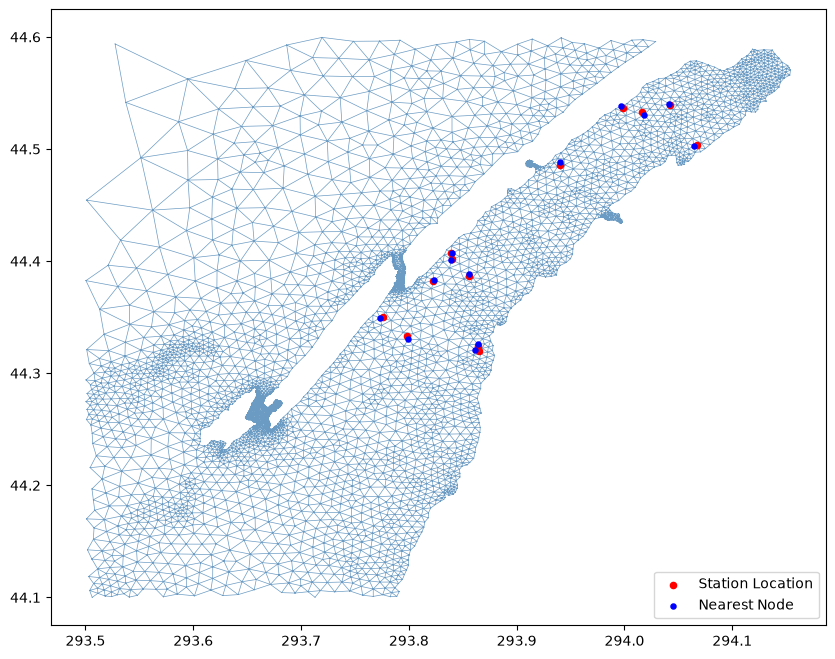

In [123]:
# Plot stations with nearest nodes on mesh for a sanity check
# Extract and format triangles
# Slice the first dimension (time) - the mesh doesn't change over time
nv = stmb_fvcom.nv.values[0]
# Convert to 0-based indexing
nv = nv - 1 if nv.min() == 1 else nv
triangles = nv.T if nv.shape[0] == 3 else nv

# Create triangulation object
triangulation = tri.Triangulation(node_lon, node_lat, triangles=triangles)

# --- Plotting ---
fig, ax = plt.subplots(figsize=(10,8))

# Plot wireframe of triangles with high z-order and visible colour
ax.triplot(triangulation, color="steelblue", linewidth=0.5, alpha=0.8, zorder=1)

# Plot stations
ax.scatter(
    station_location_data["longitude_360"],
    station_location_data["latitude"],
    color="red",
    s=20,
    label="Station Location",
    zorder=3
)

# Plot nearest nodes
ax.scatter(
    node_lon[station_location_data["nearest_node"]],
    node_lat[station_location_data["nearest_node"]],
    color="blue", 
    s=10, 
    linewidths=1.5,
    label="Nearest Node", 
    zorder=3
)

ax.autoscale()
ax.legend()
plt.show()

In [ ]:
# Extract time series at each nearest node